# GUIA RAPIDA PARA EXPONER LA LIMPIEZA

Este notebook muestra como se preparo el dataset antes de entrenar modelos. La idea principal es convertir el Excel original en un archivo limpio y confiable para predecir `PM 2.5`.

Flujo que debes explicar:

1. Se carga el Excel original de contaminacion horaria de Lima.
2. Se revisan columnas, tipos de datos y valores faltantes.
3. Se convierten contaminantes a numeros, porque los modelos matematicos no trabajan con texto.
4. Se eliminan duplicados de una misma estacion, fecha y hora.
5. Se rellenan valores faltantes de variables predictoras como `PM 10`, `SO2`, `NO2`, `O3` y `CO`.
6. No se inventa `PM 2.5`; si falta la variable objetivo, esa fila no sirve para entrenar.
7. Se guardan `datos_limpios.csv` y `datos_modelo.csv` para los modelos.

### Comentario para exposicion: eliminacion de duplicados

Se eliminan registros repetidos usando estacion, ano, mes, dia y hora. La razon es que una misma estacion no deberia tener dos mediciones iguales para la misma hora.

**Importación de librerías**

In [26]:
import pandas as pd #Libreria para manipular, limpiar y analizar datos (.csv, .xlsx, SQL, JSON)
import numpy as np #Libreria para realizar cálculos matemáticos sobre arrays
import matplotlib.pyplot as plt #Libreria para Visualizar Dato en gráficos
import seaborn as sns #Libreria que se construye sobre matplotlib para graficos complejos

**Carga del dataset**

### Comentario para exposicion: carga del dataset

Aqui se lee el archivo Excel original. Este archivo es el dataset sucio, por eso todavia puede tener nulos, duplicados o columnas con valores que parecen numeros pero estan guardados como texto.

In [27]:
df = pd.read_excel('../data/raw/datos_horarios_contaminacion_lima.xlsx')

**Inspección inicial del dataset**

### Comentario para exposicion: inspeccion inicial

En esta parte reviso el tamano del dataset, nombres de columnas y primeros registros. Esto sirve para entender que variables existen y confirmar que `PM 2.5` sera la variable objetivo.

In [28]:
print("Tamaño del dataset:")
print(df.shape)

print("\nColumnas:")
print(df.columns)

print("\nTipos de datos:")
print(df.dtypes)

print("\nPrimeras filas:")
print(df.head())

print("\nÚltimas filas:")
print(df.tail())

Tamaño del dataset:
(703056, 12)

Columnas:
Index(['CODIGO ESTACION', 'ESTACION', 'ANO', 'MES', 'DIA', 'HORA', 'PM 10',
       'PM 2.5', 'SO2', 'NO2', 'O3', 'CO'],
      dtype='str')

Tipos de datos:
CODIGO ESTACION      int64
ESTACION               str
ANO                  int64
MES                  int64
DIA                  int64
HORA                 int64
PM 10              float64
PM 2.5             float64
SO2                float64
NO2                float64
O3                 float64
CO                 float64
dtype: object

Primeras filas:
   CODIGO ESTACION ESTACION   ANO  MES  DIA  HORA   PM 10  PM 2.5   SO2   NO2  \
0           112192      ATE  2010    4    1     0     NaN     NaN  39.8   NaN   
1           112192      ATE  2010    4    1     1  135.69     NaN  29.9  47.2   
2           112192      ATE  2010    4    1     2  135.84     NaN  26.5  44.1   
3           112192      ATE  2010    4    1     3  119.06     NaN  25.9  41.4   
4           112192      ATE  2010    4  

**Visualización inicial de valores nulos**

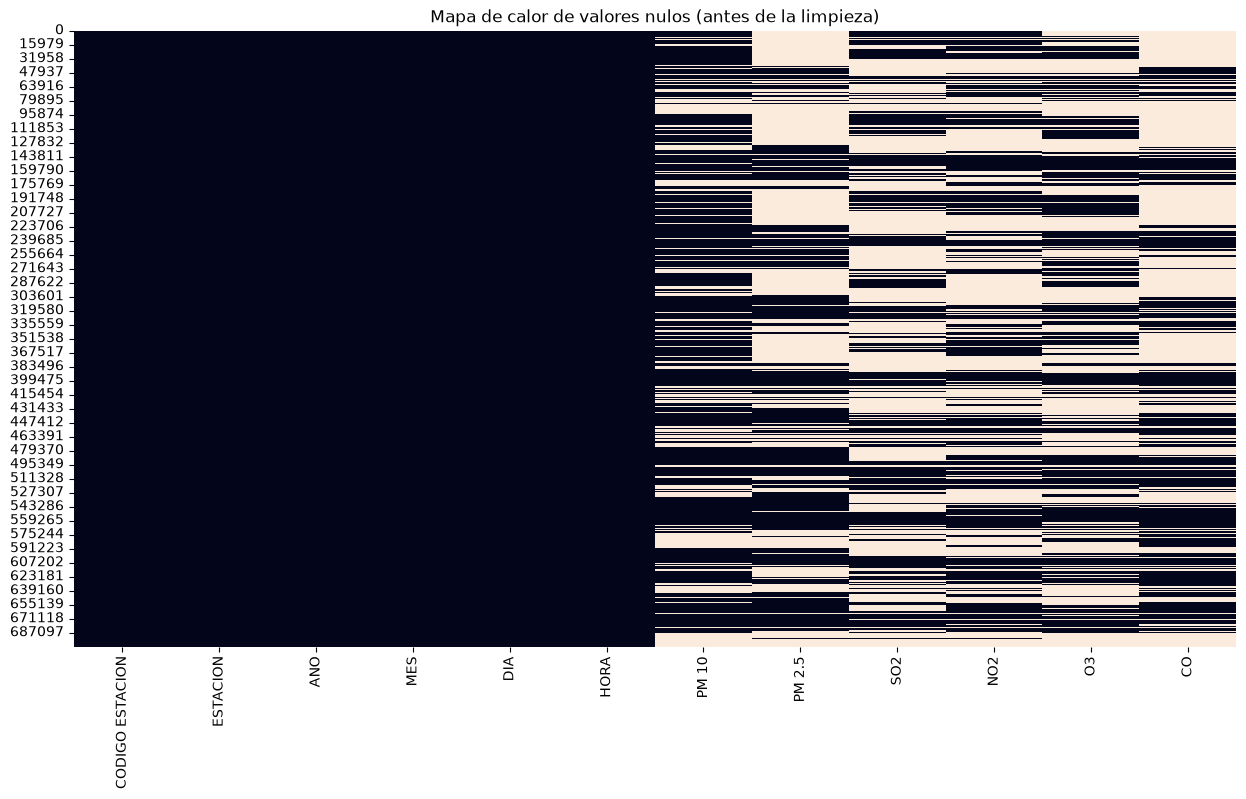

In [29]:
plt.figure(figsize=(15,8))
sns.heatmap(df.isnull(),cbar=False,cmap="rocket")
plt.title("Mapa de calor de valores nulos (antes de la limpieza)")
plt.show()

**Conversión de contaminantes a numéricos**

### Comentario para exposicion: conversion a numerico

Los contaminantes deben estar como numeros para poder hacer calculos y entrenar modelos. Si vienen con coma decimal o como texto, se convierten a formato numerico.

In [30]:
contaminantes = ["PM 10","PM 2.5","SO2","NO2","O3","CO"]
for col in contaminantes:
    df[col] = (df[col].astype(str).str.replace(",", ".", regex=False))
    df[col] = pd.to_numeric(df[col],errors="coerce")

**Verificar tipos y porcentaje de nulos**

In [31]:
print("\nTipos de datos:")
print(df.dtypes)
print("\nPorcentaje de nulos:")
print((df[contaminantes].isnull().mean()*100).round(2)) #Con mean obtenemos la media y *100 para obtener el porcentaje con dos decimales


Tipos de datos:
CODIGO ESTACION      int64
ESTACION               str
ANO                  int64
MES                  int64
DIA                  int64
HORA                 int64
PM 10              float64
PM 2.5             float64
SO2                float64
NO2                float64
O3                 float64
CO                 float64
dtype: object

Porcentaje de nulos:
PM 10     29.35
PM 2.5    51.64
SO2       58.14
NO2       50.04
O3        50.40
CO        54.29
dtype: float64


**Eliminación de duplicados**

In [32]:
duplicados = df.duplicated(subset=["CODIGO ESTACION","ANO","MES","DIA","HORA"])
print("Duplicados encontrados:",duplicados.sum())

df = df.drop_duplicates(subset=["CODIGO ESTACION","ANO","MES","DIA","HORA"])
print("Duplicados después de eliminar:",df.duplicated(subset=["CODIGO ESTACION","ANO","MES","DIA","HORA"]).sum())

Duplicados encontrados: 9
Duplicados después de eliminar: 0


**Nulos antes de la imputación**

In [33]:
print("ANTES DE LA IMPUTACIÓN:")
print((df[contaminantes].isnull().mean()*100).round(2))

ANTES DE LA IMPUTACIÓN:
PM 10     29.35
PM 2.5    51.64
SO2       58.14
NO2       50.04
O3        50.40
CO        54.29
dtype: float64


**Interpolación temporal (lineal)**

### Comentario para exposicion: imputacion de valores faltantes

Para variables de entrada se pueden rellenar algunos faltantes. Primero se interpola dentro de cada estacion, porque los datos son horarios y tienen continuidad temporal. Luego se usa la mediana por estacion y hora como respaldo.

In [34]:
for col in contaminantes:
    df[col] = df.groupby("CODIGO ESTACION")[col].transform(lambda x: x.interpolate(method="linear",limit=6,limit_direction="both"))
print("DESPUÉS DEL NIVEL 1:")
print((df[contaminantes].isnull().mean()*100).round(2))

DESPUÉS DEL NIVEL 1:
PM 10     28.24
PM 2.5    50.64
SO2       57.18
NO2       48.73
O3        49.19
CO        53.27
dtype: float64


**Mediana por estación + hora**

In [35]:
for col in contaminantes:
    df[col] = df[col].fillna( df.groupby(["CODIGO ESTACION","HORA"])[col].transform("median"))
print("DESPUÉS DEL NIVEL 2:")
print((df[contaminantes].isnull().mean()*100).round(2))

DESPUÉS DEL NIVEL 2:
PM 10     0.0
PM 2.5    0.0
SO2       0.0
NO2       0.0
O3        0.0
CO        0.0
dtype: float64


**Heatmap después de la imputación**

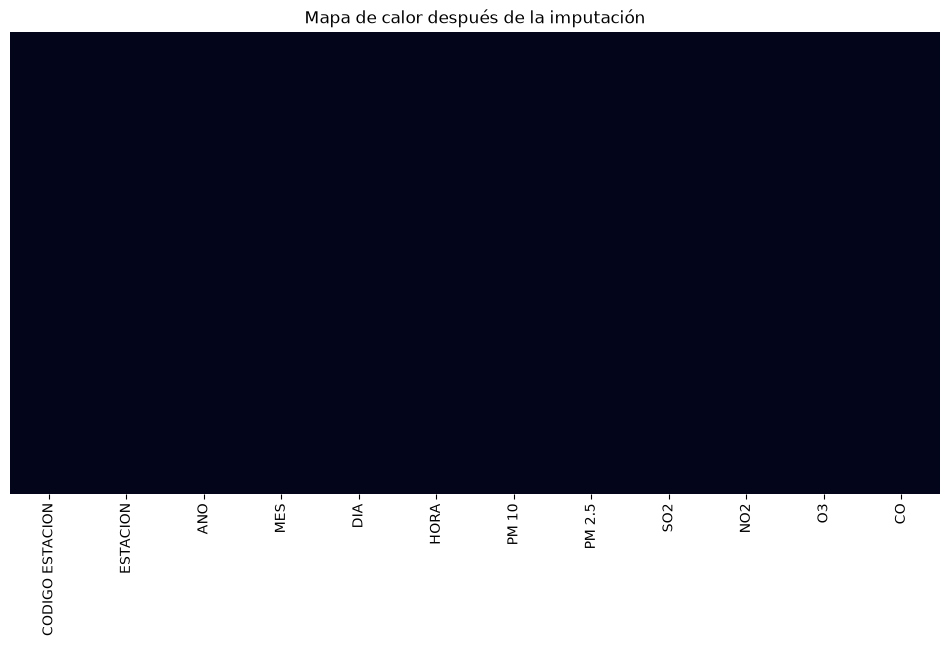

In [36]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=False,yticklabels=False)
plt.title("Mapa de calor después de la imputación")
plt.show()

**Validacion**




### Comentario para exposicion: validacion final

Aqui se revisa que la limpieza no haya dejado valores problematicos. Lo mas importante es conservar filas donde exista `PM 2.5`, porque ese valor real se necesita para que el modelo aprenda.

In [37]:
print("Nulos finales:")
print(df[contaminantes].isnull().sum())

Nulos finales:
PM 10     0
PM 2.5    0
SO2       0
NO2       0
O3        0
CO        0
dtype: int64


**Encontramos una fila con todos los valores nulos (eliminamos)**

In [38]:
df[df[contaminantes].isnull().any(axis=1)]

,CODIGO ESTACION,ESTACION,ANO,MES,DIA,HORA,PM 10,PM 2.5,SO2,NO2,O3,CO


In [39]:
df = df.dropna(subset=contaminantes)
print(df[contaminantes].isnull().sum())

PM 10     0
PM 2.5    0
SO2       0
NO2       0
O3        0
CO        0
dtype: int64


Graficas de la Investigación

### Comentario para exposicion: graficas exploratorias

Estas graficas no entrenan el modelo, pero ayudan a entender el comportamiento de los datos: distribucion de contaminantes, valores por estacion y patrones generales.

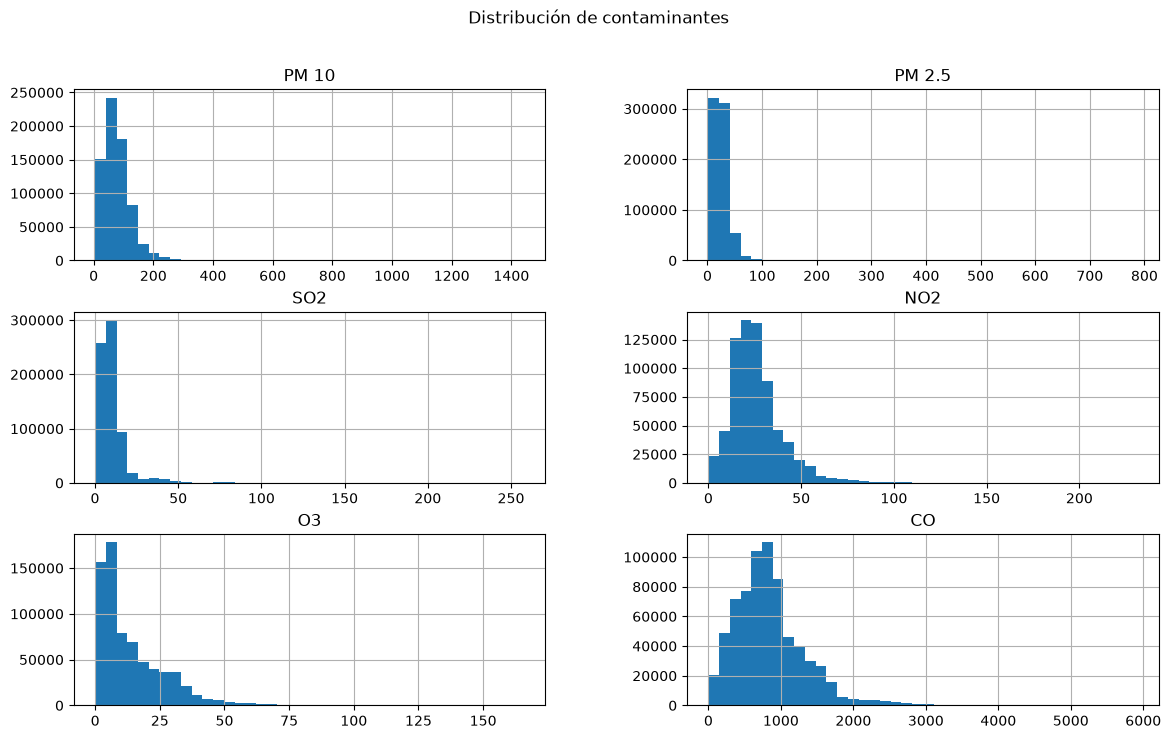

In [40]:
contaminantes = ["PM 10","PM 2.5","SO2","NO2","O3","CO"]
df[contaminantes].hist(figsize=(14,8),bins=40)
plt.suptitle("Distribución de contaminantes")
plt.show()

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[contaminantes])
plt.title("Boxplot de contaminantes")
plt.show()

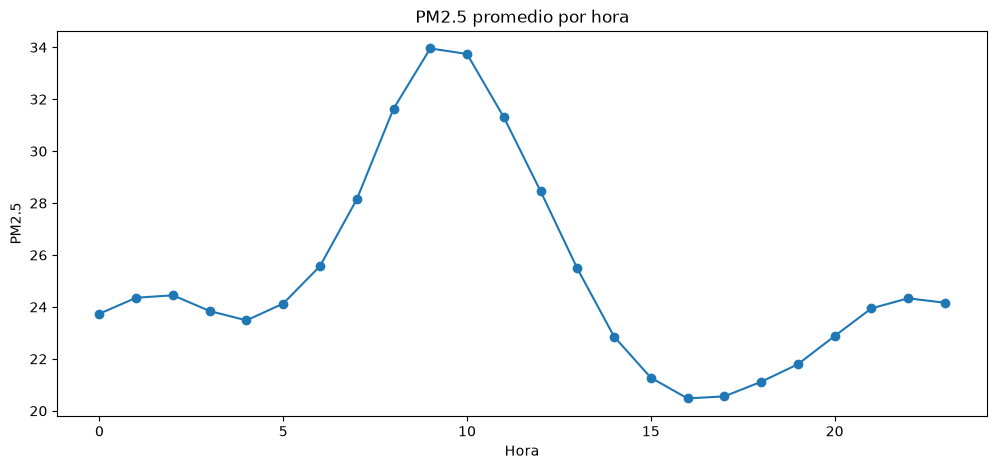

In [ ]:
plt.figure(figsize=(12,5))
df.groupby("HORA")["PM 2.5"].mean().plot(marker="o")
plt.title("PM2.5 promedio por hora")
plt.xlabel("Hora")
plt.ylabel("PM2.5")
plt.show()

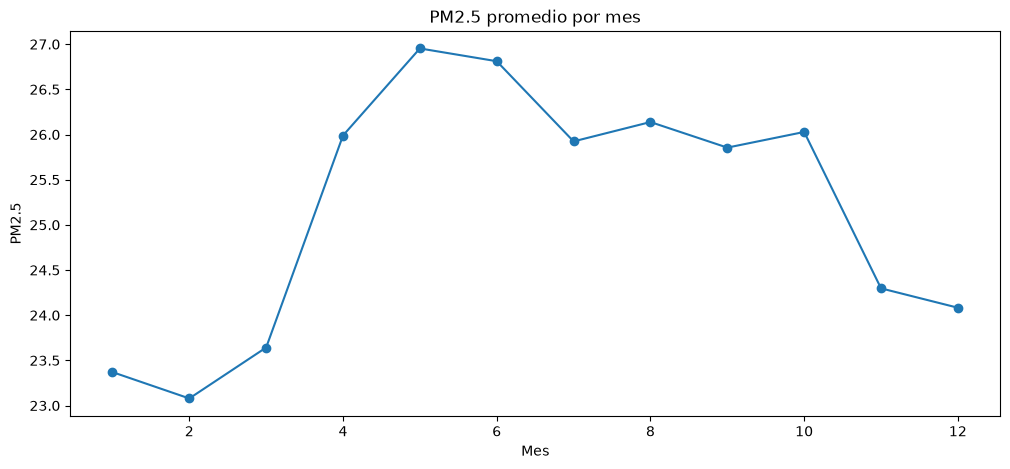

In [ ]:
plt.figure(figsize=(12,5))
df.groupby("MES")["PM 2.5"].mean().plot(marker="o")
plt.title("PM2.5 promedio por mes")
plt.xlabel("Mes")
plt.ylabel("PM2.5")
plt.show()

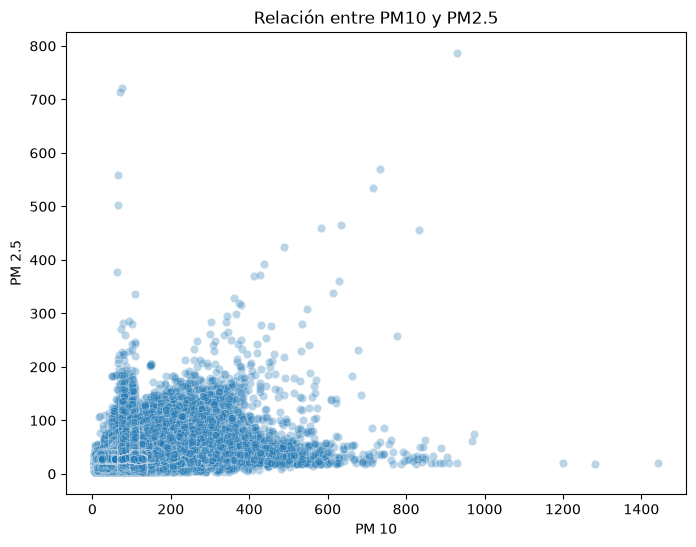

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x="PM 10",y="PM 2.5",alpha=0.3)
plt.title("Relación entre PM10 y PM2.5")
plt.show()

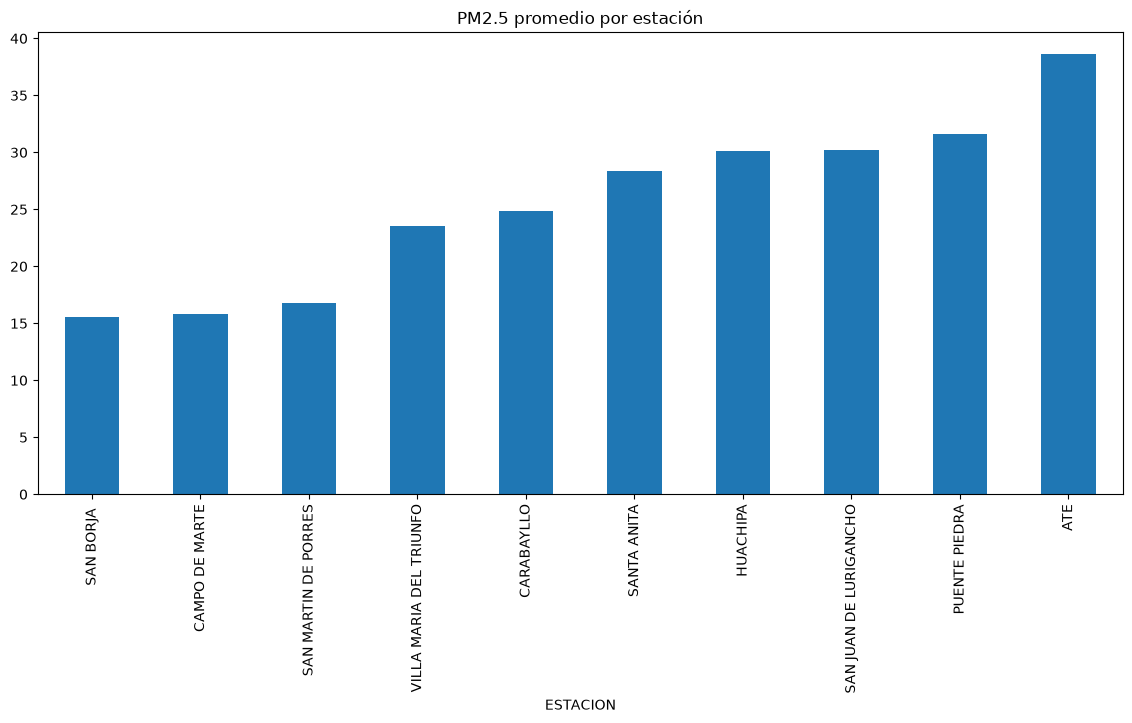

In [ ]:
plt.figure(figsize=(14,6))
df.groupby("ESTACION")["PM 2.5"].mean().sort_values().plot(kind="bar")
plt.title("PM2.5 promedio por estación")
plt.show()

In [ ]:
df.to_excel('datos_horarios_contaminacion_lima_limpio.xlsx', index=False)
print("Dataset limpio guardado como 'datos_horarios_contaminacion_lima_limpio.xlsx'")

Dataset limpio guardado como 'datos_horarios_contaminacion_lima_limpio.xlsx'


## GRAFICOS GENERADOS PARA LA LIMPIEZA

### Graficos de apoyo para explicar el dataset

Estas imagenes vienen de la carpeta `reports/imagenes`. Sirven para mostrar visualmente la distribucion de `PM 2.5` despues de la limpieza.

Distribucion de PM2.5


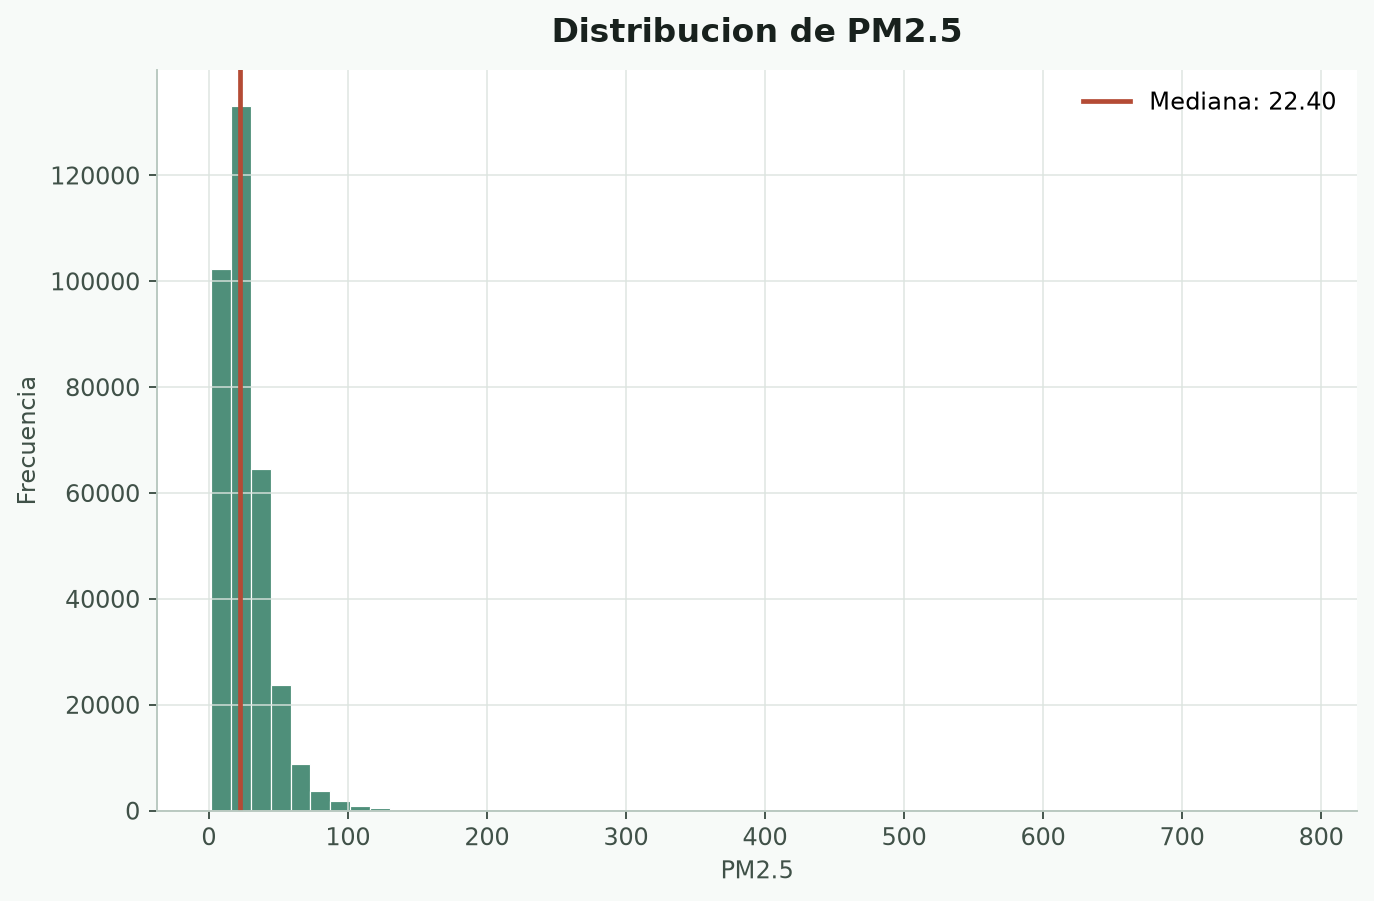

In [ ]:
from IPython.display import Image, display
from pathlib import Path
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
IMAGE_DIR = PROJECT_DIR / 'reports' / 'imagenes'

print('Distribucion de PM2.5')
display(Image(filename=str(IMAGE_DIR / 'distribucion_pm25.png')))